In [1]:
ls

algorithm_mine.py                     diffusion_postprocessor.py
algorithm.py                          diffusion_training_mine.py
custom_wrapper.py                     eval_mine_cifar100.py
ddpm_ood_postprocessor_mine.py        eval_mine.py
ddpm_ood_postprocessor.py             eval_mine_test.py
diffpath_postprocessor_mine.py        eval.py
diffpath_postprocessor.py             hyperpara_finetune.ipynb
diffusion_model_manager_mine.py       model_unet.py
diffusion_model_manager.py            msma_postprocessor_mine.py
diffusion_nll_postprocessor_mine.py   msma_postprocessor.py
diffusion_nll_postprocessor.py        __pycache__/
diffusion_postprocessor_mine.py       resnet50_openood.py
diffusion_postprocessor_mine_test.py  trained_diffusion_ckpts/


In [2]:
cd ..

/home/robine/dummy_diff


/home/robine/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
pip install -r requirements.txt

  Cloning https://github.com/Jingkang50/OpenOOD to /tmp/pip-req-build-fsjmza9z
  Running command git clone --filter=blob:none --quiet https://github.com/Jingkang50/OpenOOD /tmp/pip-req-build-fsjmza9z
  Resolved https://github.com/Jingkang50/OpenOOD to commit 2b32e52065b97c333e22a4608b7002cd2998b9d1
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [4]:
cd src

/home/robine/dummy_diff/src


In [5]:
import torch
import pandas as pd
from openood.evaluation_api import Evaluator
from openood.networks import ResNet18_32x32
from diffusion_postprocessor_mine import CustomDiffusionPostprocessor
from ddpm_ood_postprocessor_mine import DdpmOODPostprocessor
from diffpath_postprocessor_mine import DiffPathPostprocessor
from msma_postprocessor_mine import MSMAPostprocessor
from diffusion_nll_postprocessor_mine import DiffusionNllPostprocessor
from diffusion_model_manager_mine import set_trained_diffusion_model
from model_unet import DiscreteDDPMProcess, UniformDiscreteTimeSampler, DiffusionModel
import dataclasses
import timm

/home/robine/.conda/envs/my_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
cd ..

/home/robine/dummy_diff


/home/robine/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [7]:
config = {
        'postprocessor': {
            'name': 'custom_diffusion_postprocessor.CustomDiffusionPostprocessor',
            'APS_mode': False,
            'diffusion_args': {
                # Diffusion process parameters
                'num_diffusion_timesteps': 5000,
                'schedule_type': 'linear',
                
                
                # Training parameters
                'train_loop': {
                    'batch_size': 4096*4,
                    'eta_min' : 3e-12,
                    'lr': 3e-4,
                    'warmup_steps': 1000,
                    'total_steps': 25000,  # Reduced for testing
                    'max_step': 1000+25000,
                },
                    'unet': {
        'activation': 'elu',
        'time_embedding_dim': 1024*5
    }
            },
            'integration_method': {
                # Reference point optimization
                'kmeans_k': 40,
                'asc_steps': 10000,
                'asc_lr': 1e-2,
                'asc_grad_clip': 10.0,
                'asc_wd': 0.0,
                
                # Score integration
                'gauss_n': 25,
                'gauss_batch': 5000,
                
                # Convergence criteria
                'asc_convergence_window': 1000,
                'asc_convergence_threshold': 5e-1,
                'asc_min_steps': 100,
                
                # Device settings
                'device': 'cuda'
            },
            'ddpmood_args': {
            'ood_t' : 250,
            'num_inference_steps' : 100,
        },
            'diffpath_args': {
            'n_steps': 20,#20,
            'batch_size': 2048,
            'device': 'cuda',
        },
            'msma_args': {
                'n_steps': 20,
                'batch_size': 2048,
                'device': 'cuda',
            },
            'diffusion_nll': {
                'batch_size': 2048*2,
                'device': 'cuda',
            },
    }
}
    #Load the diffusion model
diffusion_params = config['postprocessor']['diffusion_args']
net_config = config['postprocessor']['integration_method']
checkpoint = torch.load('model_checkpoint_latent_linear_100.pth')
diffusion_process = DiscreteDDPMProcess(num_diffusion_timesteps=diffusion_params['num_diffusion_timesteps'],schedule_type=diffusion_params['schedule_type'])
time_sampler = UniformDiscreteTimeSampler(diffusion_process.tmin, diffusion_process.tmax)
unet_params = diffusion_params['unet']
@dataclasses.dataclass
class NetConfig:
    activation: str = unet_params.get('activation')
    time_embedding_dim: int = unet_params.get('time_embedding_dim')

diffusion_model = DiffusionModel(
    diffusion_process=diffusion_process,
    time_sampler=time_sampler,
    net_config=NetConfig(),
    data_shape=(512,)
).cuda()
diffusion_model.load_state_dict(checkpoint['model_state_dict'])
diffusion_model.eval()
diffusion_model.cuda()

DiffusionModel(
  (net_fwd): Net(
    (_time_encoder): SinusoidalTimeEmbedding()
    (_predictor): UNet1D(
      (act): ELU(alpha=1.0)
      (down1): Conv1d(1, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (down2): Conv1d(64, 128, kernel_size=(4,), stride=(2,), padding=(1,))
      (down3): Conv1d(128, 256, kernel_size=(4,), stride=(2,), padding=(1,))
      (down4): Conv1d(256, 512, kernel_size=(4,), stride=(2,), padding=(1,))
      (time_emb): Linear(in_features=5120, out_features=512, bias=True)
      (up1): ConvTranspose1d(512, 256, kernel_size=(4,), stride=(2,), padding=(1,))
      (up2): ConvTranspose1d(512, 128, kernel_size=(4,), stride=(2,), padding=(1,))
      (up3): ConvTranspose1d(256, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (up4): ConvTranspose1d(128, 1, kernel_size=(4,), stride=(2,), padding=(1,))
    )
  )
)

In [11]:
net = ResNet18_32x32(num_classes=100)
net.load_state_dict(torch.load(
    'pretrained_models/cifar100_resnet18_32x32_base_e100_lr0.1_default/s0/best.ckpt'
))
net.cuda().eval()

ResNet18_32x32(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1,

In [17]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from openood.networks import ResNet18_32x32

# Path configuration
ID_NAME = 'cifar100'
DATA_ROOT = './data'

def create_cifar100_loader(batch_size=256):
    """Create a CIFAR-100 training data loader using torchvision"""
    
    # Define transforms for CIFAR-100
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],  # CIFAR-100 mean
            std=[0.2675, 0.2565, 0.2761]    # CIFAR-100 std
        )
    ])
    
    # Load CIFAR-100 dataset
    print("Loading CIFAR-100 training dataset...")
    train_dataset = datasets.CIFAR100(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    
    # Create training data loader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4
    )
    
    print(f"Training dataset size: {len(train_dataset)}")
    print(f"Number of batches: {len(train_loader)}")
    
    return {'train': train_loader}

# Create data loader
id_loader_dict = create_cifar100_loader(batch_size=256)

# Load the pretrained model
net = ResNet18_32x32(num_classes=100)
net.load_state_dict(torch.load(
    'pretrained_models/cifar100_resnet18_32x32_base_e100_lr0.1_default/s0/best.ckpt'
))
net.cuda().eval()

print("CIFAR-100 training loader and model ready!")

Loading CIFAR-100 training dataset...
Training dataset size: 50000
Number of batches: 196
CIFAR-100 training loader and model ready!


In [18]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

def extract_features(net, loader_dict):
    """Extract features from the training data"""
    feats_list = []
    labels_list = []
    
    print("Extracting features from training data...")
    with torch.no_grad():
        for images, labels in tqdm(loader_dict['train']):
            images = images.cuda()
            # Extract features using your model's feature extraction capability
            _, feats = net(images, return_feature=True)
            feats_list.append(feats.cpu())
            labels_list.append(labels)
    
    # Concatenate all features and labels
    all_feats = torch.cat(feats_list, dim=0)
    all_labels = torch.cat(labels_list, dim=0)
    
    print(f"Extracted features shape: {all_feats.shape}")
    print(f"Labels shape: {all_labels.shape}")
    
    # Compute normalization statistics
    train_mean = all_feats.mean(dim=0, keepdim=True)
    train_std = all_feats.std(dim=0, keepdim=True) + 1e-6
    
    # Normalize features
    normalized_feats = (all_feats - train_mean) / train_std
    
    print(f"Normalized features shape: {normalized_feats.shape}")
    print(f"Mean of normalized features: {normalized_feats.mean():.6f}")
    print(f"Std of normalized features: {normalized_feats.std():.6f}")
    
    return {
        'raw_features': all_feats, 
        'normalized_features': normalized_feats.cuda(), 
        'labels': all_labels,
        'train_mean': train_mean.cuda(),
        'train_std': train_std.cuda()
    }

# Extract and normalize features
feature_data = extract_features(net, id_loader_dict)

Extracting features from training data...


100%|████████████████████| 196/196 [00:09<00:00, 20.72it/s]


Extracted features shape: torch.Size([50000, 512])
Labels shape: torch.Size([50000])
Normalized features shape: torch.Size([50000, 512])
Mean of normalized features: -0.000000
Std of normalized features: 0.999988


In [122]:
print(feature_data['raw_features'].shape)
torch.save(feature_data['raw_features'].cpu(),"feature_cifar_100.pt")

torch.Size([50000, 512])


In [8]:
feature_data = torch.load("feature_cifar_100.pt", map_location="cpu")

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm.auto import tqdm
from time import time
import torch
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import torch
from collections import deque
from tqdm.auto import tqdm

def optimize_reference_point(
    model,
    initial_x,                          # shape  [batch, latent_dim]
    num_steps: int            = 10_000,
    lr: float                 = 5e-4,
    max_grad_norm: float      = 10.0,
    weight_decay: float       = 0.0,
    lr_scheduler=None,                  
    convergence_window: int   = 500,
    convergence_threshold: float = 1e-1,
    min_steps: int            = 100,
    device: str               = "cuda",
):
    """
    Score-based gradient ascent with a cosine LR schedule.
    Returns the optimised latent points `x` (same shape as `initial_x`).
    """

    # -------- shape & device --------
    if initial_x.dim() == 1:
        initial_x = initial_x.unsqueeze(0)
    x = torch.nn.Parameter(initial_x.clone().to(device))

    # -------- optimiser & cosine LR --------
    optimiser = torch.optim.Adam([x], lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser,
        T_max=num_steps,
        eta_min=1e-5,           # hard-coded final LR
    )

    # -------- convergence bookkeeping --------
    batch_size   = x.shape[0]
    history = []
    window_score = deque(maxlen=convergence_window + 1)        # CPU
    active_mask  = torch.ones(batch_size, dtype=torch.bool, device=device)

    # -------- main loop --------
    with tqdm(total=num_steps, desc="Batch Score Ascent") as pbar:
        for step in range(num_steps):
            optimiser.zero_grad()

            # forward pass on all points
            score  = -model.net_fwd(x, torch.zeros(x.size(0), device=device))
            norms  = score.norm(dim=1)   # GPU  [batch]
            current_max = norms.max().item()

            # store norms on CPU for the sliding window
            norms_cpu = norms.detach().cpu()
            history.append(norms_cpu)
            window_score.append(norms_cpu)

            # gradient ascent for active points only
            x.grad = torch.zeros_like(x)
            x.grad[active_mask] = -score[active_mask]

            if max_grad_norm:
                torch.nn.utils.clip_grad_norm_([x], max_grad_norm)

            optimiser.step()
            scheduler.step()             # cosine decay

            # ---------- convergence check ----------
            if (
                step > min_steps
                and len(window_score) == window_score.maxlen
            ):
                w    = torch.stack(tuple(window_score))          # [win, batch]
                rms  = w.diff(dim=0).pow(2).mean(dim=0).sqrt()  # diagnostic

                stayed_low = (w < convergence_threshold).all(dim=0)
                active_mask[stayed_low.to(device)] = False

                pbar.set_postfix(
                    active    = f"{active_mask.sum().item()}/{batch_size}",
                    max_score = f"{current_max:.2e}",
                    max_rms   = f"{rms.max():.2e}",
                    lr        = f"{optimiser.param_groups[0]['lr']:.2e}",
                )

            pbar.update(1)
            if not active_mask.any():
                break
    history = torch.stack(history) 
    return x.detach(), history

In [114]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0).fit(feature_data['raw_features'].cpu())
centroids = torch.tensor(kmeans.cluster_centers_, device='cuda', dtype=torch.float32)
print(centroids.shape)

torch.Size([2, 512])


In [115]:
opt_x, score_history = optimize_reference_point(
    model=diffusion_model,
    initial_x=centroids,
    num_steps=50000,
    lr=5e-3,
    max_grad_norm=10.0,
    weight_decay=0.0,
    device='cuda'
)

TypeError: optimize_reference_point() got an unexpected keyword argument 'model'

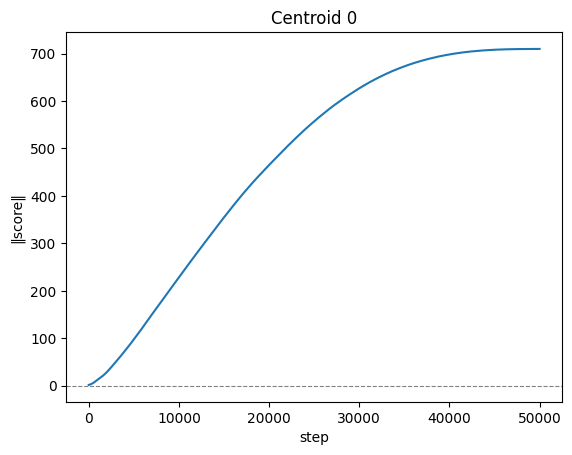

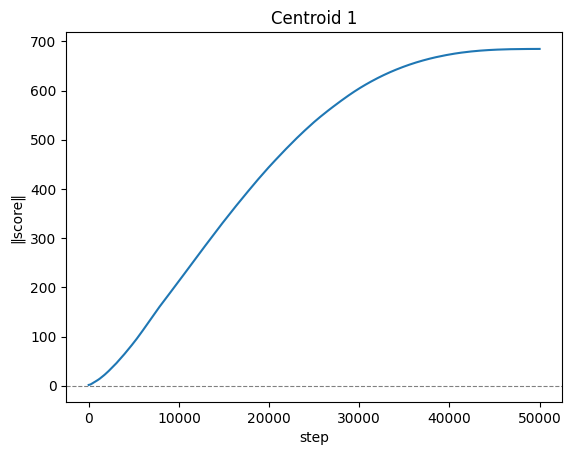

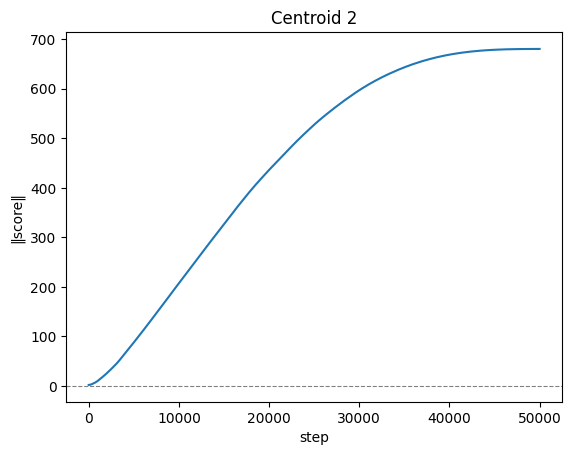

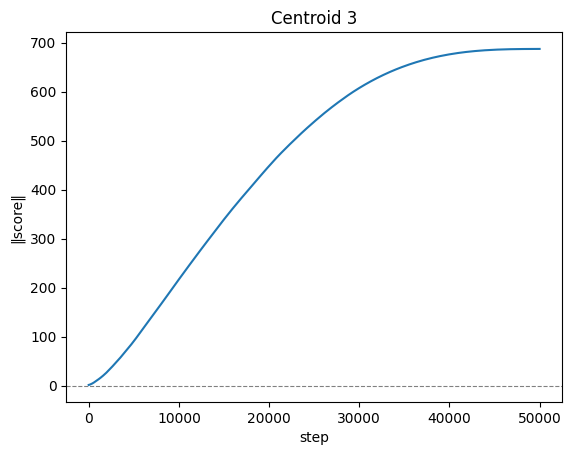

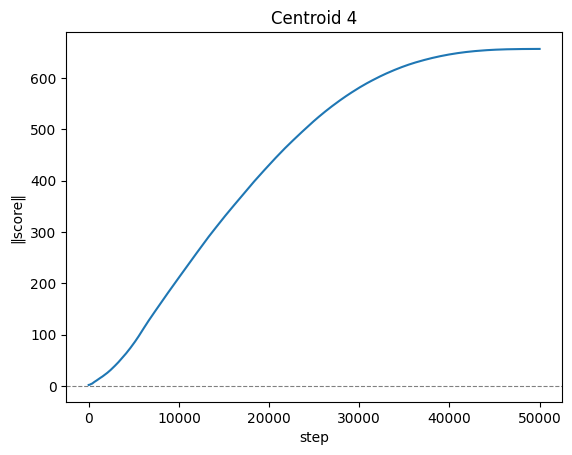

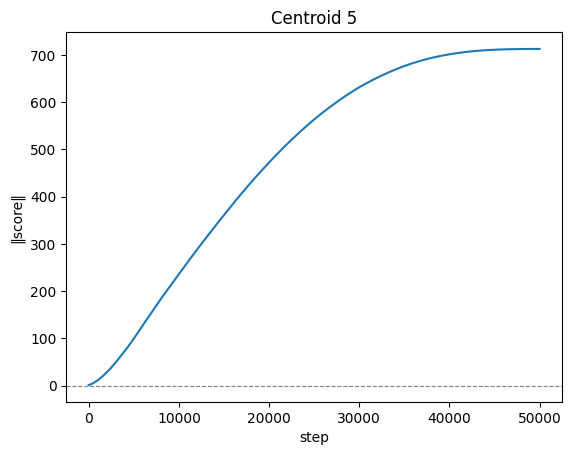

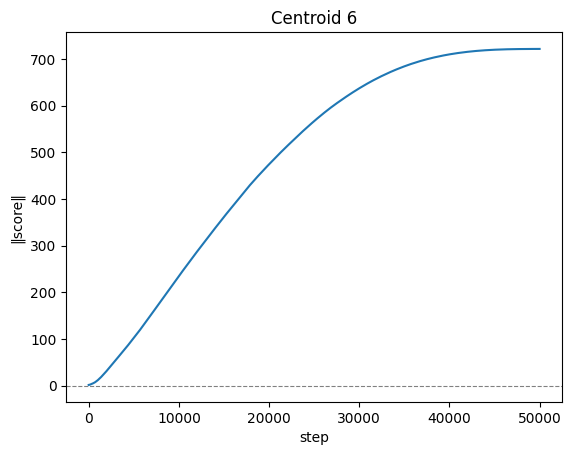

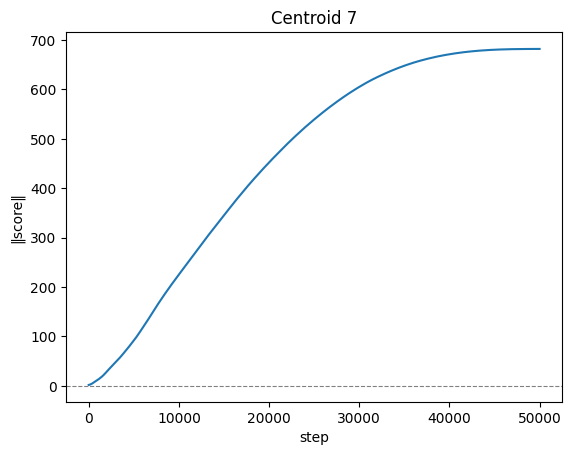

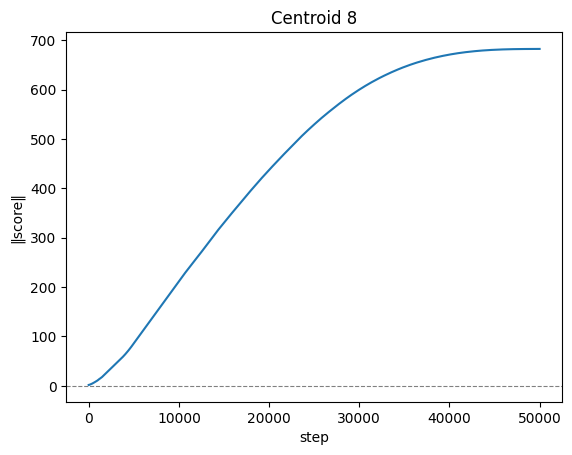

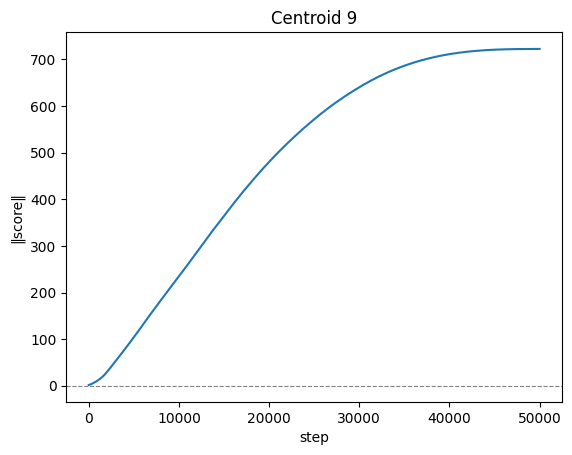

In [52]:
import matplotlib.pyplot as plt
t = torch.arange(score_history.size(0))
for k in range(score_history.size(1)):
    plt.figure()
    plt.plot(t, score_history[:, k])
    plt.title(f"Centroid {k}")
    plt.xlabel("step"); plt.ylabel("‖score‖")
    plt.axhline(1e-3, ls="--", lw=0.8, color="gray")


In [116]:
def optimize_reference_point(
    initial_x: torch.Tensor,
    *,
    num_steps: int            = 20000,
    lr: float                 = 1e-4,
    max_grad_norm: float      = 10.0,
    weight_decay: float       = 1e-5,
    # ---- NEW API ----------------------------------------------------------
    scheduler_type: str       = "cosine",      # "cosine" | "step" | "exp" | "plateau" | "none"
    scheduler_kwargs: dict    = None,          # hyper-params for the chosen scheduler
    # ----------------------------------------------------------------------
    convergence_window: int   = 500,
    convergence_threshold: float = 1e-1,
    min_steps: int            = 100,
    device: str               = "cuda",
):
    """
    Optimises a batch of latent vectors by score-based gradient ascent and
    returns (final_x, history).

    Parameters
    ----------
    scheduler_type : {"cosine", "step", "exp", "plateau", "none"}
        Type of learning-rate decay to use.
    scheduler_kwargs : dict or None
        Extra arguments passed verbatim to the chosen scheduler.
        When None, sensible defaults are filled in automatically.

    Examples
    --------
    >>> # cosine annealing 1e-4 -> 1e-6 over the whole run
    >>> optimize_reference_point(x0, scheduler_type="cosine")
    >>> # step decay every 3 000 steps
    >>> optimize_reference_point(x0, scheduler_type="step",
    ...                          scheduler_kwargs=dict(step_size=3000, gamma=0.3))
    >>> # keep a constant LR
    >>> optimize_reference_point(x0, scheduler_type="none")
    """
    # ---------- scheduler defaults ----------
    if scheduler_kwargs is None:
        scheduler_kwargs = {}

    if scheduler_type == "cosine":
        scheduler_kwargs.setdefault("T_max", num_steps)
        scheduler_kwargs.setdefault("eta_min", 1e-6)
    elif scheduler_type == "step":
        scheduler_kwargs.setdefault("step_size", num_steps // 3)
        scheduler_kwargs.setdefault("gamma", 0.3)
    elif scheduler_type in {"exp", "exponential"}:
        scheduler_kwargs.setdefault("gamma", 0.9999)
    elif scheduler_type == "plateau":
        scheduler_kwargs.setdefault("mode", "max")
        scheduler_kwargs.setdefault("factor", 0.5)
        scheduler_kwargs.setdefault("patience", 500)

    # ---------- tensor setup ----------
    if initial_x.dim() == 1:
        initial_x = initial_x.unsqueeze(0)
    x = torch.nn.Parameter(initial_x.clone().to(device))

    optimiser = torch.optim.Adam([x], lr=lr, weight_decay=weight_decay)

    # ---------- build scheduler ----------
    scheduler_type = scheduler_type.lower()
    if scheduler_type == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimiser, **scheduler_kwargs
        )
    elif scheduler_type == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimiser, **scheduler_kwargs
        )
    elif scheduler_type in {"exp", "exponential"}:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(
            optimiser, **scheduler_kwargs
        )
    elif scheduler_type == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimiser, **scheduler_kwargs
        )
    elif scheduler_type == "none":
        scheduler = None
    else:
        raise ValueError(f"Unknown scheduler_type '{scheduler_type}'")

    # ---------- book-keeping ----------
    batch   = x.shape[0]
    history = []
    window  = deque(maxlen=convergence_window + 1)
    active  = torch.ones(batch, dtype=torch.bool, device=device)

    # ---------- optimisation loop ----------
    with tqdm(total=num_steps, desc="Batch Score Ascent") as bar:
        for step in range(num_steps):
            optimiser.zero_grad()

            score  = -diffusion_model.net_fwd(x, torch.ones(x.size(0), device=device))
            norms  = score.norm(dim=1)
            current_max = norms.max().item()           # GPU  [batch]

            # ---- logging (CPU) ----
            norms_cpu = norms.detach().cpu()
            history.append(norms_cpu)
            window.append(norms_cpu)

            # ---- gradient for active centroids ----
            x.grad = torch.zeros_like(x)
            x.grad[active] = -score[active]

            if max_grad_norm:
                torch.nn.utils.clip_grad_norm_([x], max_grad_norm)

            optimiser.step()

            # ---- update learning rate ----
            if scheduler is not None:
                if scheduler_type == "plateau":
                    scheduler.step(norms.max().item())
                else:
                    scheduler.step()

            # ---- convergence check ----
            if step > min_steps and len(window) == window.maxlen:
                w    = torch.stack(tuple(window))           # CPU
                rms  = w.diff(dim=0).pow(2).mean(dim=0).sqrt()
                stayed_low = (w < convergence_threshold).all(dim=0)
                active[stayed_low.to(device)] = False

                bar.set_postfix(
                    active=f"{active.sum().item()}/{batch}",
                    max_score = f"{current_max:.2e}",
                    max_rms  = f"{rms.max():.2e}",
                    lr=f"{optimiser.param_groups[0]['lr']:.2e}",
                )

            bar.update(1)
            if not active.any():
                break

    history = torch.stack(history)          # CPU [steps, batch]
    return x.detach().cpu(), history

Batch Score Ascent: 100%|██████| 20000/20000 [01:27<00:00, 228.80it/s, active=2/2, lr=1.35e-05, max_rms=7.06e-06, max_score=2.47e+00]


IndexError: index 2 is out of bounds for dimension 1 with size 2

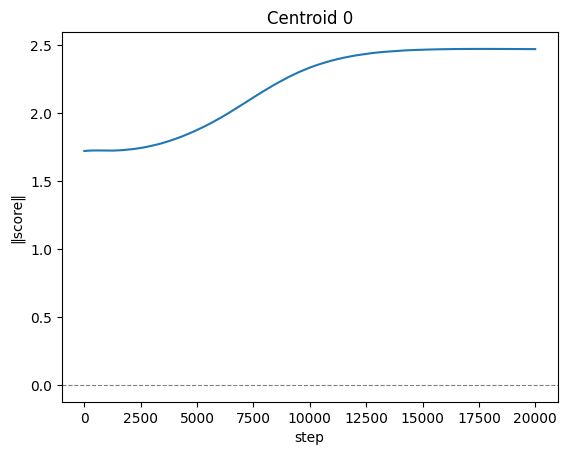

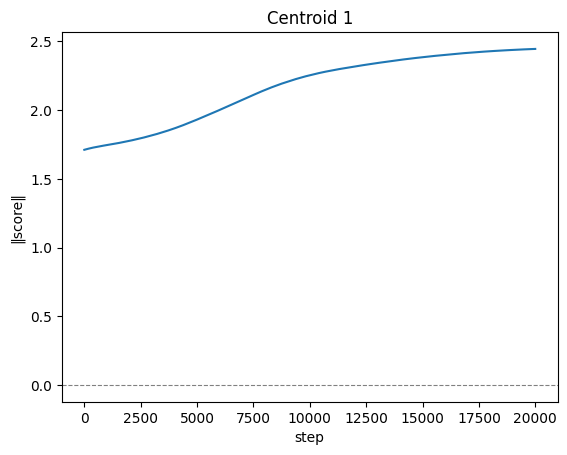

<Figure size 640x480 with 0 Axes>

In [117]:
opt_x, score_history = optimize_reference_point(centroids,
                                       scheduler_type="exp")

import matplotlib.pyplot as plt
t = torch.arange(score_history.size(0))
for k in range(15):
    plt.figure()
    plt.plot(t, score_history[:, k])
    plt.title(f"Centroid {k}")
    plt.xlabel("step"); plt.ylabel("‖score‖")
    plt.axhline(1e-3, ls="--", lw=0.8, color="gray")


In [119]:
def generate_batch(batch_size):
    # use torche's random choice function to sample from latent space
    idx = torch.randint(0, feature_data['raw_features'].shape[0], (batch_size,))
    return feature_data['raw_features'][idx]

In [121]:
import torch
import math
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from torch import optim
import pytorch_warmup as warmup
from typing import List

from model_unet import DiscreteDDPMProcess, UniformDiscreteTimeSampler, DiffusionModel, device

BATCH_SIZE=1024*4
import dataclasses

@dataclasses.dataclass
class NetConfig:
    activation: str = 'elu'
    time_embedding_dim: int = 1024


# create the model
diffusion_process = DiscreteDDPMProcess(num_diffusion_timesteps=1000,schedule_type='linear')
time_sampler = UniformDiscreteTimeSampler(diffusion_process.tmin, diffusion_process.tmax)
model = DiffusionModel(diffusion_process, time_sampler, net_config=NetConfig(), data_shape=(512,)).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)

training_steps = 20000
warmup_period=1000
num_steps = training_steps
t0 = num_steps // 1
lr_min = 3e-12
max_step = t0 * 1 + warmup_period

lr_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=t0, T_mult=1, eta_min=lr_min)

warmup_scheduler = warmup.LinearWarmup(optimizer, warmup_period)


BATCH_SIZE=1024*4

for step in range(training_steps):
    x0 = generate_batch(BATCH_SIZE).to(device)
    optimizer.zero_grad()
    loss = model.loss(x0)
    loss.backward()
    optimizer.step()
    if step % 500 == 0:
        print(f'Step: {step}, Loss: {loss:.5f}')
    with warmup_scheduler.dampening():
        if warmup_scheduler.last_step + 1 >= warmup_period:
            lr_scheduler.step()
        if warmup_scheduler.last_step + 1 >= max_step:
            break

Step: 0, Loss: 3.34695
Step: 500, Loss: 0.17885
Step: 1000, Loss: 0.15781
Step: 1500, Loss: 0.14844
Step: 2000, Loss: 0.14297
Step: 2500, Loss: 0.14048
Step: 3000, Loss: 0.13166
Step: 3500, Loss: 0.12747
Step: 4000, Loss: 0.12992
Step: 4500, Loss: 0.12303
Step: 5000, Loss: 0.12544
Step: 5500, Loss: 0.12966
Step: 6000, Loss: 0.12028
Step: 6500, Loss: 0.12181
Step: 7000, Loss: 0.12432
Step: 7500, Loss: 0.12402
Step: 8000, Loss: 0.11876
Step: 8500, Loss: 0.12382
Step: 9000, Loss: 0.12300
Step: 9500, Loss: 0.11418
Step: 10000, Loss: 0.11803
Step: 10500, Loss: 0.11868


KeyboardInterrupt: 